In [1]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
# import healpy as hp

import treecorr

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/1.1.1/resolve/dr9_lrg_1.1.1_basic.fits'))
lrgmask = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/1.1.1/resolve/dr9_lrg_1.1.1_lrgmask_v1.1.fits.gz'))
pixel = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/1.1.1/resolve/dr9_lrg_1.1.1_pixel.fits'))
cat = hstack([cat, lrgmask, pixel], join_type='exact')
print(len(cat))

12338990


In [4]:
mask = cat['DEC']>-25
cat = cat[mask]
print(len(cat))

min_nobs = 1
mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

10194195
10171577


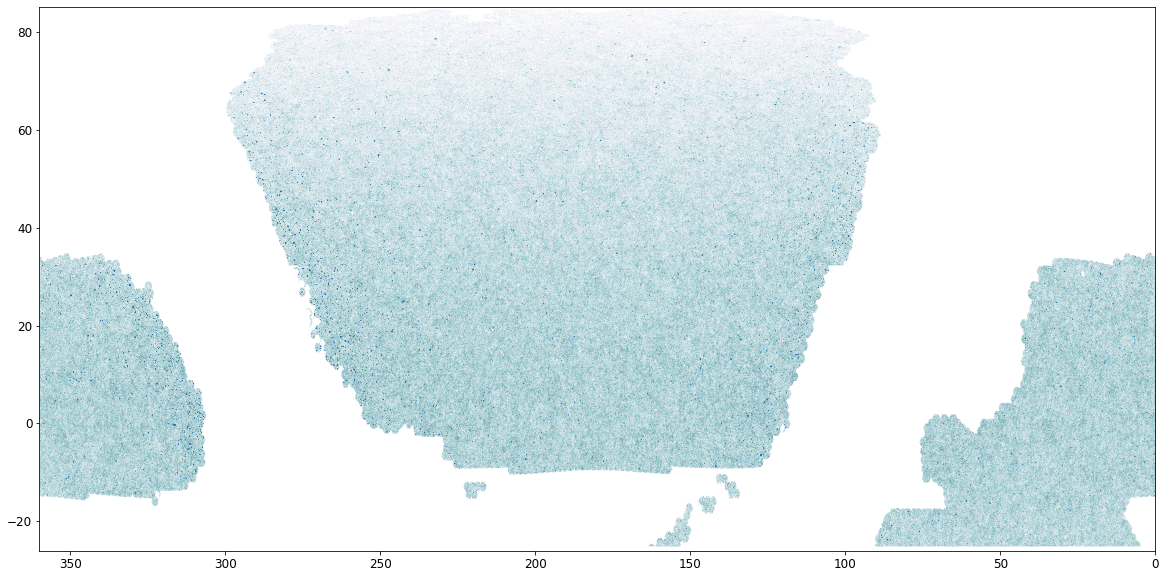

In [5]:
plt.figure(figsize=(20, 10))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1, alpha=0.05)
plt.axis([360, 0, -26, 85])
plt.show()

In [6]:
nomask = np.full(len(cat), True)
print(np.sum(~nomask)/len(nomask))

dr9mask = np.full(len(cat), True)
dr9_maskbits = [1, 8, 9, 11, 12, 13]
for bit in dr9_maskbits:
    dr9mask &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~dr9mask)/len(dr9mask))

lrgmask = cat['lrg_mask']==0
print(np.sum(~lrgmask)/len(lrgmask))

0.0
0.10528131478530812
0.12601634928389177


In [7]:
lrg_south = cat['PHOTSYS']=='S'
lrg_north = cat['PHOTSYS']=='N'
print(np.sum(lrg_south)/len(lrg_south))
print(np.sum(lrg_north)/len(lrg_north))

0.6865603042674701
0.31343969573252994


In [8]:
randoms_path = '/Users/rongpu/Downloads/tmp/randoms-1-0.fits'

randoms_columns = ['RA', 'DEC',  'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS']
randoms = Table(fitsio.read(randoms_path, columns=randoms_columns))
randoms_lrgmask = Table(fitsio.read('/Users/rongpu/Downloads/tmp/randoms-1-0-lrgmask_v1.1.fits.gz'))
randoms = hstack([randoms, randoms_lrgmask], join_type='exact')
print(len(randoms))
randoms_density = fitsio.read_header(randoms_path, ext=1)['DENSITY']
print(randoms_density)

51738616
2500


In [9]:
mask = randoms['DEC']>-25
randoms = randoms[mask]
print(len(randoms))

mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
randoms = randoms[mask]
print(len(randoms))

randoms_nomask = np.ones(len(randoms), dtype=bool)

randoms_dr9mask = np.ones(len(randoms), dtype=bool)
for bit in dr9_maskbits:
    randoms_dr9mask &= (randoms['MASKBITS'] & 2**bit)==0
print(np.sum(~randoms_dr9mask)/len(randoms_dr9mask))

randoms_lrgmask = randoms['lrg_mask']==0
print(np.sum(~randoms_lrgmask)/len(randoms_lrgmask))

print()
print(np.sum((~randoms_lrgmask) & randoms_south)/np.sum(randoms_south))
print(np.sum((~randoms_lrgmask) & randoms_north)/np.sum(randoms_north))

42125164
40312410
0.07030142826985536
0.08930768465591613


0.08160667309757111
0.10613151092954064


In [10]:
randoms_south = randoms['PHOTSYS']=='S'
randoms_north = randoms['PHOTSYS']=='N'

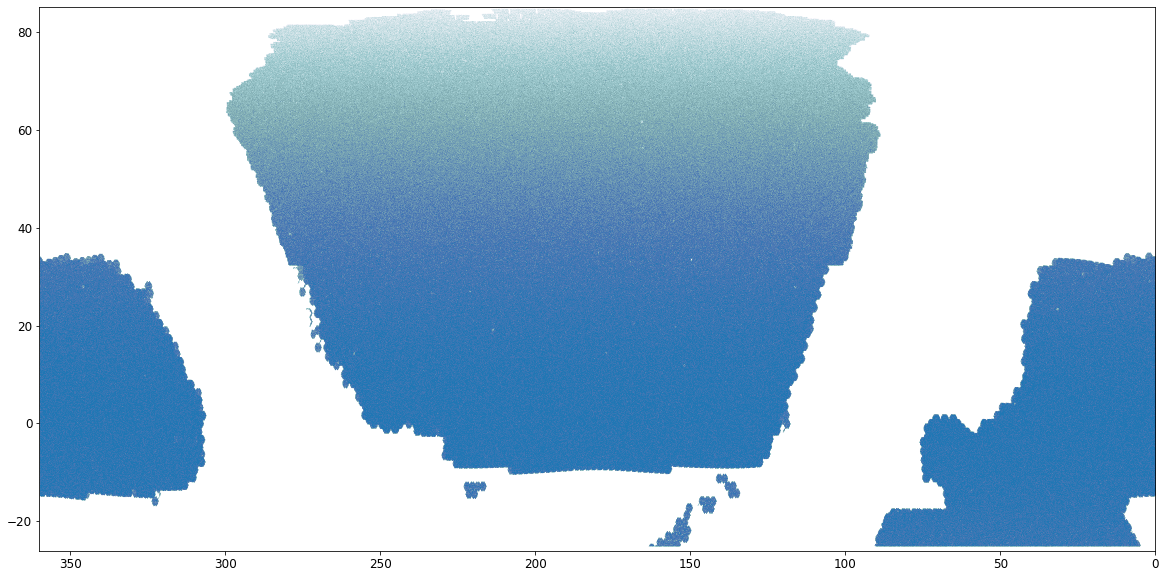

In [11]:
plt.figure(figsize=(20, 10))
plt.plot(randoms['RA'], randoms['DEC'], '.', ms=0.1, alpha=0.05)
plt.axis([360, 0, -26, 85])
plt.show()

-------

In [12]:
def angular_corr(ra_obs, dec_obs, ra_rand, dec_rand, 
    min_sep, max_sep, bin_size, verbose=True):
    '''
    Compute angular correlation.
    '''
    # LRGs
    cat = treecorr.Catalog(ra=ra_obs, dec=dec_obs, ra_units='deg', dec_units='deg')
    # randoms
    rand = treecorr.Catalog(ra=ra_rand, dec=dec_rand, ra_units='deg', dec_units='deg')

    t1 = time.time()
    dd = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, bin_size=bin_size, sep_units='degrees')
    dd.process(cat)
    rr = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, bin_size=bin_size, sep_units='degrees')
    rr.process(rand)
    dr = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, bin_size=bin_size, sep_units='degrees')
    dr.process(cat, rand)
    t2 = time.time()

    xi, varxi = dd.calculateXi(rr, dr)
    xierr = np.sqrt(varxi)
    r = np.exp(dd.meanlogr)

    if verbose:
        print('{:.1f} sec'.format(t2-t1))

    return(xi, r, xierr)

------
# Small scale

In [14]:
xi_south, r_south, sig_south = angular_corr(cat['RA'][lrg_south & lrgmask], cat['DEC'][lrg_south & lrgmask], 
                          randoms['RA'][randoms_south], randoms['DEC'][randoms_south], 
                          min_sep=0.0001, max_sep=0.1, bin_size=0.1, verbose=True)

40.8 sec


In [15]:
xi_north, r_north, sig_north = angular_corr(cat['RA'][lrg_north & lrgmask], cat['DEC'][lrg_north & lrgmask], 
                          randoms['RA'][randoms_north], randoms['DEC'][randoms_north], 
                          min_sep=0.0001, max_sep=0.1, bin_size=0.1, verbose=True)

17.2 sec


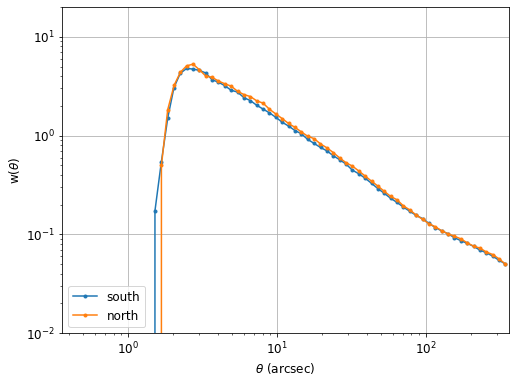

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(r_south*3600, xi_south, '.-', label='south')
plt.plot(r_north*3600, xi_north, '.-', label='north')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (arcsec)')
plt.ylabel(r'w($\theta)$')
plt.legend(loc='lower left')
plt.xlim(0.0001*3600, 0.1*3600)
plt.ylim(1e-2, 20)
plt.grid()
plt.show()

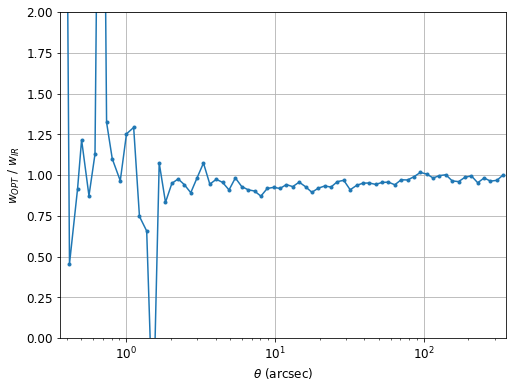

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(r_north*3600, xi_south/xi_north, '.-')
plt.xscale('log')
# plt.yscale('log', nonposy='clip')
plt.xlabel(r'$\theta$ (arcsec)')
plt.ylabel(r'$w_{south}$ / $w_{north}$')
plt.xlim(0.0001*3600, 0.1*3600)
plt.ylim(0., 2)
plt.grid()
plt.show()

------
# Larger scale

74.3 sec
31.5 sec


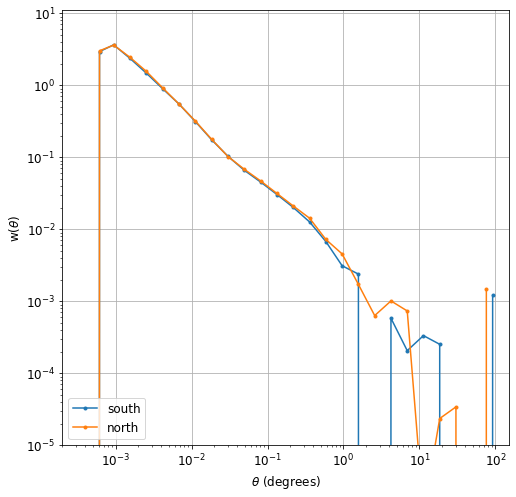

In [37]:
xi_south, r_south, sig_south = angular_corr(cat['RA'][lrg_south & lrgmask], cat['DEC'][lrg_south & lrgmask], 
                          randoms['RA'][randoms_south & randoms_lrgmask], randoms['DEC'][randoms_south & randoms_lrgmask], 
                          min_sep=0.0001, max_sep=100, bin_size=0.5, verbose=True)

xi_north, r_north, sig_north = angular_corr(cat['RA'][lrg_north & lrgmask], cat['DEC'][lrg_north & lrgmask], 
                          randoms['RA'][randoms_north & randoms_lrgmask], randoms['DEC'][randoms_north & randoms_lrgmask], 
                          min_sep=0.0001, max_sep=100, bin_size=0.5, verbose=True)

t = Table()
t['xi'], t['r'], t['sig'] = xi_south, r_south, sig_south
t.write('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_south_lrgmask.txt', format='ascii.commented_header', overwrite=True)

t = Table()
t['xi'], t['r'], t['sig'] = xi_north, r_north, sig_north
t.write('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_north_lrgmask.txt', format='ascii.commented_header', overwrite=True)

plt.figure(figsize=(8, 8))
plt.plot(r_south, xi_south, '.-', label='south')
plt.plot(r_north, xi_north, '.-', label='north')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'w($\theta)$')
plt.legend(loc='lower left')
plt.xlim(0.0002, 150)
plt.ylim(1e-5, 11)
plt.grid()
plt.show()

73.6 sec
36.5 sec


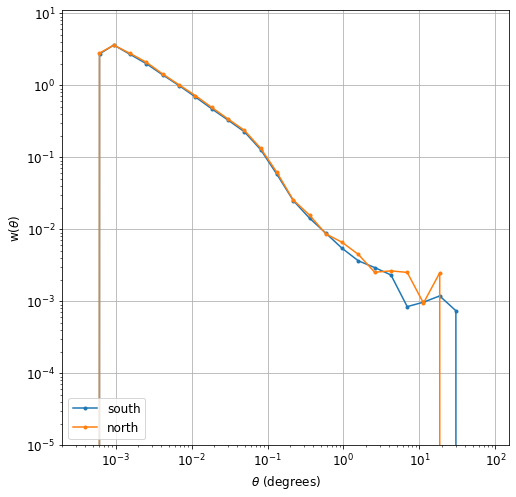

In [38]:
xi_south, r_south, sig_south = angular_corr(cat['RA'][lrg_south & nomask], cat['DEC'][lrg_south & nomask], 
                          randoms['RA'][randoms_south & randoms_nomask], randoms['DEC'][randoms_south & randoms_nomask], 
                          min_sep=0.0001, max_sep=100, bin_size=0.5, verbose=True)

xi_north, r_north, sig_north = angular_corr(cat['RA'][lrg_north & nomask], cat['DEC'][lrg_north & nomask], 
                          randoms['RA'][randoms_north & randoms_nomask], randoms['DEC'][randoms_north & randoms_nomask], 
                          min_sep=0.0001, max_sep=100, bin_size=0.5, verbose=True)

t = Table()
t['xi'], t['r'], t['sig'] = xi_south, r_south, sig_south
t.write('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_south_nomask.txt', format='ascii.commented_header', overwrite=True)

t = Table()
t['xi'], t['r'], t['sig'] = xi_north, r_north, sig_north
t.write('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_north_nomask.txt', format='ascii.commented_header', overwrite=True)

plt.figure(figsize=(8, 8))
plt.plot(r_south, xi_south, '.-', label='south')
plt.plot(r_north, xi_north, '.-', label='north')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'w($\theta)$')
plt.legend(loc='lower left')
plt.xlim(0.0002, 150)
plt.ylim(1e-5, 11)
plt.grid()
plt.show()

69.1 sec
30.3 sec


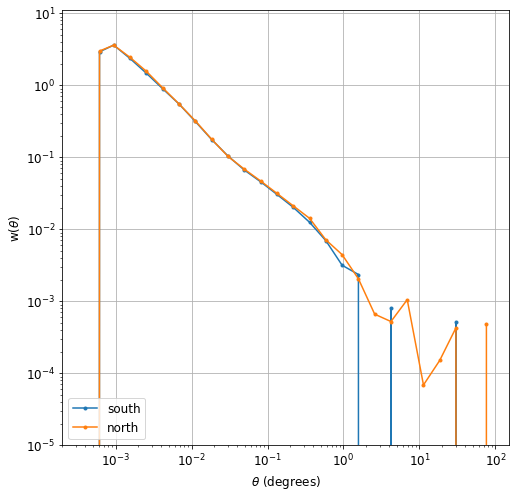

In [39]:
xi_south, r_south, sig_south = angular_corr(cat['RA'][lrg_south & dr9mask], cat['DEC'][lrg_south & dr9mask], 
                          randoms['RA'][randoms_south & randoms_dr9mask], randoms['DEC'][randoms_south & randoms_dr9mask], 
                          min_sep=0.0001, max_sep=100, bin_size=0.5, verbose=True)

xi_north, r_north, sig_north = angular_corr(cat['RA'][lrg_north & dr9mask], cat['DEC'][lrg_north & dr9mask], 
                          randoms['RA'][randoms_north & randoms_dr9mask], randoms['DEC'][randoms_north & randoms_dr9mask], 
                          min_sep=0.0001, max_sep=100, bin_size=0.5, verbose=True)

t = Table()
t['xi'], t['r'], t['sig'] = xi_south, r_south, sig_south
t.write('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_south_dr9mask.txt', format='ascii.commented_header', overwrite=True)

t = Table()
t['xi'], t['r'], t['sig'] = xi_north, r_north, sig_north
t.write('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_north_dr9mask.txt', format='ascii.commented_header', overwrite=True)

plt.figure(figsize=(8, 8))
plt.plot(r_south, xi_south, '.-', label='south')
plt.plot(r_north, xi_north, '.-', label='north')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'w($\theta)$')
plt.legend(loc='lower left')
plt.xlim(0.0002, 150)
plt.ylim(1e-5, 11)
plt.grid()
plt.show()

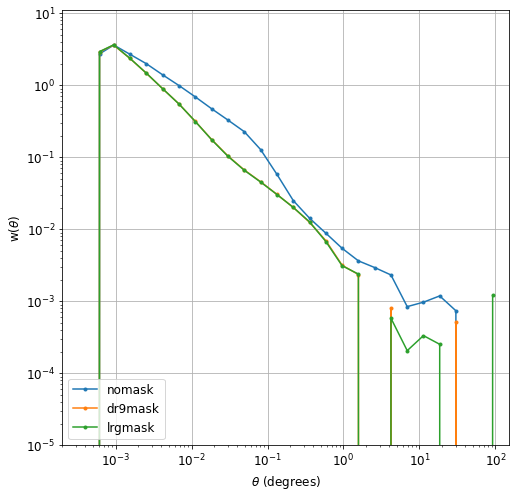

In [40]:
t1 = Table.read('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_south_nomask.txt', format='ascii.commented_header')
t2 = Table.read('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_south_dr9mask.txt', format='ascii.commented_header')
t3 = Table.read('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_south_lrgmask.txt', format='ascii.commented_header')

plt.figure(figsize=(8, 8))
plt.plot(t1['r'], t1['xi'], '.-', label='nomask')
plt.plot(t2['r'], t2['xi'], '.-', label='dr9mask')
plt.plot(t3['r'], t3['xi'], '.-', label='lrgmask')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'w($\theta)$')
plt.legend(loc='lower left')
plt.xlim(0.0002, 150)
plt.ylim(1e-5, 11)
plt.grid()
plt.show()

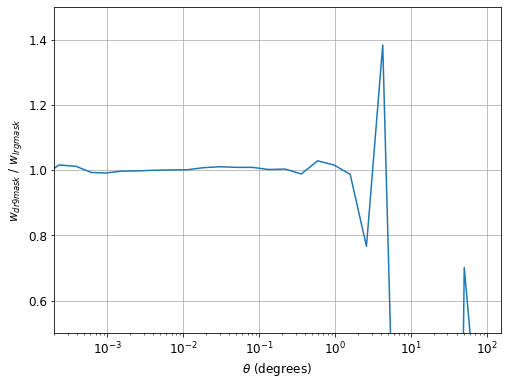

In [43]:
plt.figure(figsize=(8, 6))
plt.plot(t2['r'], t2['xi']/t3['xi'])
plt.xscale('log')
# plt.yscale('log', nonposy='clip')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{dr9mask}$ / $w_{lrgmask}$')
plt.xlim(0.0002, 150)
plt.ylim(0.5, 1.5)
plt.grid()
plt.show()

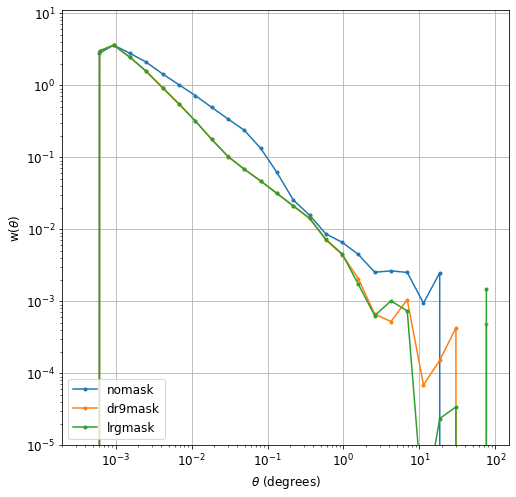

In [44]:
t1 = Table.read('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_north_nomask.txt', format='ascii.commented_header')
t2 = Table.read('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_north_dr9mask.txt', format='ascii.commented_header')
t3 = Table.read('/Users/rongpu/git/desi-targets/sv/final_selection/tmp1/lrg_north_lrgmask.txt', format='ascii.commented_header')

plt.figure(figsize=(8, 8))
plt.plot(t1['r'], t1['xi'], '.-', label='nomask')
plt.plot(t2['r'], t2['xi'], '.-', label='dr9mask')
plt.plot(t3['r'], t3['xi'], '.-', label='lrgmask')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'w($\theta)$')
plt.legend(loc='lower left')
plt.xlim(0.0002, 150)
plt.ylim(1e-5, 11)
plt.grid()
plt.show()

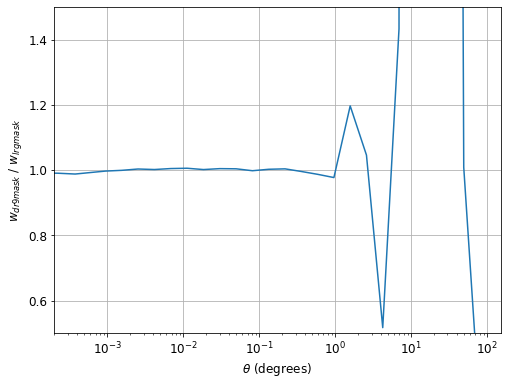

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(t2['r'], t2['xi']/t3['xi'])
plt.xscale('log')
# plt.yscale('log', nonposy='clip')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{dr9mask}$ / $w_{lrgmask}$')
plt.xlim(0.0002, 150)
plt.ylim(0.5, 1.5)
plt.grid()
plt.show()